In [2]:
import torch
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np
import os

from grid_simulation import get_rgb_map
from cuda_square_simulation import SquareSimulation
from agent import select_action, clever_single_action

%reload_ext autoreload
%autoreload 2

In [7]:
# Init policy Network

from agent import PolicyNet

obs_shape = (3, 5, 5)
policy_net = PolicyNet(obs_shape)
policy_net.load_state_dict(torch.load('policy_net.pth'))
policy_net.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
policy_net.to(device)


/home/delsad/SHS-Life-Science-Philosophy-Altruism/grid_simulation/cuda_env_project/.pixi/envs/default/lib/python3.13/site-packages/torch/nn/utils/weight_norm.py:143: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


PolicyNet(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=75, out_features=100, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc2): Linear(in_features=100, out_features=17, bias=True)
)

In [3]:
def get_results_imgs(simulation, iterations=50,  type1 = 'random', type2 = 'random', type3 = 'random', save_dir=None, title=None):

    pop1_size = []
    pop2_size = []
    pop3_size = []

    for i in range(iterations):
        if type1 == 'Reinforcement Learning Agent':
            action_grid = simulation.configurable_actions_grid(type1=None, type2=type2, type3=type3)

            with torch.no_grad():
                observations, obs_indices = simulation.get_deep_observations(0)
                action = select_action(policy_net, observations)
                action_grid = clever_single_action(simulation, action, obs_indices, type2, type3) 

        else:
            action_grid = simulation.configurable_actions_grid(type1=type1, type2=type2, type3=type3)

        simulation.step(action_grid)

        pop1_size.append(simulation.grid[:,0].sum(dim=(1,2)).mean(dim=0).cpu().numpy())
        pop2_size.append(simulation.grid[:,1].sum(dim=(1,2)).mean(dim=0).cpu().numpy())
        pop3_size.append(simulation.grid[:,2].sum(dim=(1,2)).mean(dim=0).cpu().numpy())

    # get the final population sizes
    # results = []
    # results.append(pop1_size[-1])
    # results.append(pop2_size[-1])
    # results.append(pop3_size[-1])

    # results.append(pop1_size[-1] / fitness_total * 100)
    # results.append(pop2_size[-1] / fitness_total * 100)
    # results.append(pop3_size[-1] / fitness_total * 100)

    # get the final population sizes
    string_results = '\n'
    string_results+='Final population fitness:\n'
    string_results+=f'Population 1: {type1} - {pop1_size[-1]}\n'
    string_results+=f'Population 2: {type2} - {pop2_size[-1]}\n'
    string_results+=f'Population 3: {type3} - {pop3_size[-1]}\n\n'
        
    fitness_total = pop1_size[-1] + pop2_size[-1] + pop3_size[-1]
    string_results+=f'Total fitness: {fitness_total}\n\n'

    string_results+='Final population %\'s fitness:\n'
    string_results+=f'Population 1: {type1} - {pop1_size[-1] / fitness_total * 100:.2f}%\n'
    string_results+=f'Population 2: {type2} - {pop2_size[-1] / fitness_total * 100:.2f}%\n'
    string_results+=f'Population 3: {type3} - {pop3_size[-1] / fitness_total * 100:.2f}%\n'

    print(string_results)


    # Get the final population distribution
    plt.figure()
    
    legend_elements = [
        Patch(facecolor='red', edgecolor='r', label=f'{type1.capitalize()}'),
        Patch(facecolor='blue', edgecolor='b', label=f'{type2.capitalize()}'),
        Patch(facecolor='green', edgecolor='g', label=f'{type3.capitalize()}'),
    ]   
    
    rgb_map = get_rgb_map(simulation, plt)
    plt.imshow(rgb_map)
    plt.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1.5, 1.))  
    plt.axis('off')
    plt.title('Final Population Distribution')
    if save_dir is not None:
        plt.savefig(os.path.join(save_dir, f'{title}_final_distr.pdf'), bbox_inches='tight')

    plt.show()

    # Plot the population size over time
    plt.figure()
    plt.plot(np.arange(iterations), pop1_size, label=f'{type1.capitalize()}', color='red', linestyle='--', marker='o', markersize=4, markevery=10)
    plt.plot(np.arange(iterations), pop2_size, label=f'{type2.capitalize()}', color='blue', marker='x', markersize=4, markevery=7)
    plt.plot(np.arange(iterations), pop3_size, label=f'{type3.capitalize()}', color='green', marker='s', markersize=4, markevery=13)
    plt.xlabel('Iterations')
    plt.ylabel('Population Size')
    plt.title('Population Size Over Time')
    plt.legend()
    if save_dir is not None:
        plt.savefig(os.path.join(save_dir, f'{title}_time_plot.pdf'), bbox_inches='tight')
    plt.show()

    return string_results

In [ ]:
# if save_dir is None, the images will not be saved

simulation_parameters = [('bonus_0_0', 0.0, 0.0), ('bonus_0_04', 0.0, 0.04), ('bonus_04_0', 0.04, 0.0), ('bonus_04_04', 0.04, 0.04), ('bonus_08_0', 0.08, 0.0), ('bonus_08_04', 0.08, 0.4), ('bonus_0_08', 0.0, 0.08), ('bonus_04_08', 0.04, 0.08), ('bonus_08_08', 0.08, 0.08)]

all_results_string = 'pop1 total fitness; pop2 total fitness; pop2 total fitness; pop1 \% fitness; pop 2 \% fitness; pop 3 \% fitness \n'

parent_dir = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
SAVE_DIR = os.path.join(parent_dir, 'simulation_imgs')
#SAVE_DIR = None

if SAVE_DIR is not None:
    os.makedirs(SAVE_DIR, exist_ok=True)

# Number of iterations 
iterations = 1000

# Simulation parameters
nb_batches = 5000
rows, cols = 20, 20
populations = {
    "red": {"p": 0.2, "mean_v": 1.0, "std_v": 0.1},
    "blue": {"p": 0.2, "mean_v": 1.0, "std_v": 0.1},
    "green": {"p": 0.2, "mean_v": 1.0, "std_v": 0.1},
}
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

for tup in simulation_parameters:

    sub_dir_name = tup[0]
    fitness_donation = tup[1]
    fitness_growth = tup[2]

    title = f"don_{fitness_donation}_growth_{fitness_growth}"

    print(f"Creating simulation with parameters: {sub_dir_name} - fitness_donation: {fitness_donation} - fitness_growth: {fitness_growth}")

    # Create the simulation "attack vs random"

    print("Creating simulation: attack vs random")
    simulation = SquareSimulation(nb_batch=nb_batches, rows=rows, cols=cols,
                                    populations=populations, device=device, 
                                    FITNESS_DONATION_BONUS=fitness_donation, FITNESS_GROWTH_VALUE=fitness_growth)
    simulation.reset()

    if SAVE_DIR is not None:
        tmp_dir = os.path.join(SAVE_DIR, 'attackVsRandom')
        os.makedirs(tmp_dir, exist_ok=True)
    else:
        tmp_dir = None
    results = get_results_imgs(simulation, iterations=iterations, save_dir=tmp_dir, type1='attacking', title=title)

    if SAVE_DIR is not None:
        results_string = f"Simulation: {title} - attack vs random\n{results}\n"
        all_results_string += results_string + "\n"

    print(f"Creating simulation with parameters: {sub_dir_name} - fitness_donation: {fitness_donation} - fitness_growth: {fitness_growth}")

    # Create the simulation "giving vs random"
    print("Creating simulation: giving vs random")
    simulation = SquareSimulation(nb_batch=nb_batches, rows=rows, cols=cols,
                                    populations=populations, device=device, 
                                    FITNESS_DONATION_BONUS=fitness_donation, FITNESS_GROWTH_VALUE=fitness_growth)
    simulation.reset()

    if SAVE_DIR is not None:
        tmp_dir = os.path.join(SAVE_DIR, 'givingVsRandom')
        os.makedirs(tmp_dir, exist_ok=True)
    else:
        tmp_dir = None

    results = get_results_imgs(simulation, iterations=iterations, type1='giving', save_dir=tmp_dir, title=title)

    if SAVE_DIR is not None:
        results_string = f"Simulation: {title} - giving vs random\n{results}\n"
        all_results_string += results_string + "\n"

    print(f"Creating simulation with parameters: {sub_dir_name} - fitness_donation: {fitness_donation} - fitness_growth: {fitness_growth}")

    # Create the simulation "complete vs random"
    print("Creating simulation: complete vs random")
    simulation = SquareSimulation(nb_batch=nb_batches, rows=rows, cols=cols,
                                    populations=populations, device=device, 
                                    FITNESS_DONATION_BONUS=fitness_donation, FITNESS_GROWTH_VALUE=fitness_growth)
    simulation.reset()

    if SAVE_DIR is not None:
        tmp_dir = os.path.join(SAVE_DIR, 'completeVsRandom')
        os.makedirs(tmp_dir, exist_ok=True)
    else:
        tmp_dir = None

    results = get_results_imgs(simulation, iterations=iterations, type1='complete', save_dir=tmp_dir, title=title)
    if SAVE_DIR is not None:
        results_string = f"Simulation: {title} - complete vs random\n{results}\n"
        all_results_string += results_string + "\n"

    print(f"Creating simulation with parameters: {sub_dir_name} - fitness_donation: {fitness_donation} - fitness_growth: {fitness_growth}")

    # Create the simulation "giving vs attacking vs complete"
    print("Creating simulation: complete vs giving vs attacking")
    simulation = SquareSimulation(nb_batch=nb_batches, rows=rows, cols=cols,
                                    populations=populations, device=device, 
                                    FITNESS_DONATION_BONUS=fitness_donation, FITNESS_GROWTH_VALUE=fitness_growth)
    simulation.reset()

    if SAVE_DIR is not None:
        tmp_dir = os.path.join(SAVE_DIR, 'completeVsGivingVsAttacking')
        os.makedirs(tmp_dir, exist_ok=True)
    else:
        tmp_dir = None

    results = get_results_imgs(simulation, iterations=iterations, type1='complete', type2='giving', type3='attacking', save_dir=tmp_dir, title=title)

    if SAVE_DIR is not None:
        results_string = f"Simulation: {title} - Complete vs Giving vs Attacking\n{results}\n"
        all_results_string += results_string + "\n"

    print(f"Creating simulation with parameters: {sub_dir_name} - fitness_donation: {fitness_donation} - fitness_growth: {fitness_growth}")

    # Create the simulation "Clever vs Random"
    print("Creating simulation: Reinforcement Learning Agent vs random")
    simulation = SquareSimulation(nb_batch=nb_batches, rows=rows, cols=cols,
                                    populations=populations, device=device, 
                                    FITNESS_DONATION_BONUS=fitness_donation, FITNESS_GROWTH_VALUE=fitness_growth)
    simulation.reset()

    if SAVE_DIR is not None:
        tmp_dir = os.path.join(SAVE_DIR, 'Reinforcement Learning AgentVsRandom')
        os.makedirs(tmp_dir, exist_ok=True)
    else:
        tmp_dir = None

    results = get_results_imgs(simulation, iterations=iterations, type1='Reinforcement Learning Agent', type2='random', type3='random', save_dir=tmp_dir, title=title)
    if SAVE_DIR is not None:
        results_string = f"Simulation: {title} - Reinforcement Learning Agent vs Random\n{results}\n"
        all_results_string += results_string + "\n"

    print(f"Creating simulation with parameters: {sub_dir_name} - fitness_donation: {fitness_donation} - fitness_growth: {fitness_growth}")

    # Create the simulation "Clever vs Attacker"
    print("Creating simulation: Reinforcement Learning Agent vs Attacker")
    simulation = SquareSimulation(nb_batch=nb_batches, rows=rows, cols=cols,
                                    populations=populations, device=device, 
                                    FITNESS_DONATION_BONUS=fitness_donation, FITNESS_GROWTH_VALUE=fitness_growth)
    simulation.reset()

    if SAVE_DIR is not None:
        tmp_dir = os.path.join(SAVE_DIR, 'Reinforcement Learning AgentVsAttacker')
        os.makedirs(tmp_dir, exist_ok=True)
    else:
        tmp_dir = None

    results = get_results_imgs(simulation, iterations=iterations, type1='Reinforcement Learning Agent', type2='giving', type3='giving', save_dir=tmp_dir, title=title)
    if SAVE_DIR is not None:
        results_string = f"Simulation: {title} - Reinforcement Learning Agent vs Giving\n{results}\n"
        all_results_string += results_string + "\n"

    print(f"Creating simulation with parameters: {sub_dir_name} - fitness_donation: {fitness_donation} - fitness_growth: {fitness_growth}")

    # Create the simulation "Clever vs Attacker"
    print("Creating simulation: Reinforcement Learning Agent vs Giving")
    simulation = SquareSimulation(nb_batch=nb_batches, rows=rows, cols=cols,
                                    populations=populations, device=device, 
                                    FITNESS_DONATION_BONUS=fitness_donation, FITNESS_GROWTH_VALUE=fitness_growth)
    simulation.reset()

    if SAVE_DIR is not None:
        tmp_dir = os.path.join(SAVE_DIR, 'Reinforcement Learning AgentVsGiving')
        os.makedirs(tmp_dir, exist_ok=True)
    else:
        tmp_dir = None

    results = get_results_imgs(simulation, iterations=iterations, type1='Reinforcement Learning Agent', type2='attacking', type3='attacking', save_dir=tmp_dir, title=title)
    if SAVE_DIR is not None:
        results_string = f"Simulation: {title} - Reinforcement Learning Agent vs Attacker\n{results}\n"
        all_results_string += results_string + "\n"

if SAVE_DIR is not None:
    results_txt_path = os.path.join(SAVE_DIR, "results_summary.txt")
    with open(results_txt_path, "w") as f:
        f.write(all_results_string)


Creating simulation with parameters: bonus_0_0 - fitness_donation: 0.0 - fitness_growth: 0.0
Creating simulation: attack vs random


Creating simulation with parameters: bonus_0_0 - fitness_donation: 0.0 - fitness_growth: 0.0
Creating simulation: attack vs random

Final population fitness:
Population 1: attacking - 0.0008174910908564925
Population 2: random - 0.0001351977844024077
Population 3: random - 0.0001351977844024077

Total fitness: 0.0010878866305574775

Final population %'s fitness:
Population 1: attacking - 75.14%
Population 2: random - 12.43%
Population 3: random - 12.43%



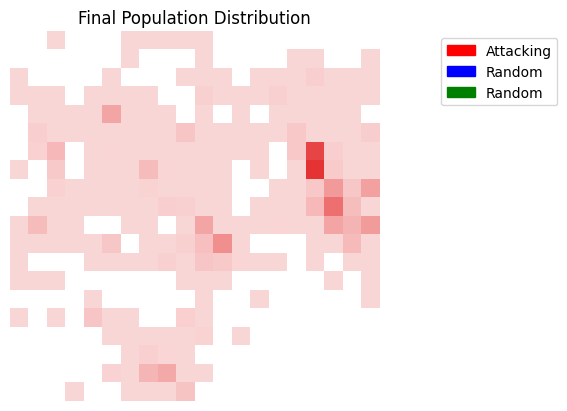

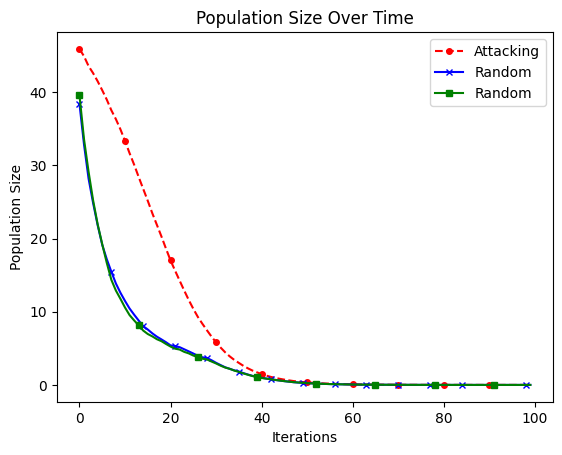

Creating simulation with parameters: bonus_0_0 - fitness_donation: 0.0 - fitness_growth: 0.0
Creating simulation: giving vs random

Final population fitness:
Population 1: giving - 0.00017331639537587762
Population 2: random - 4.6394430682994425e-05
Population 3: random - 4.6394430682994425e-05

Total fitness: 0.00026610525674186647

Final population %'s fitness:
Population 1: giving - 65.13%
Population 2: random - 17.43%
Population 3: random - 17.43%



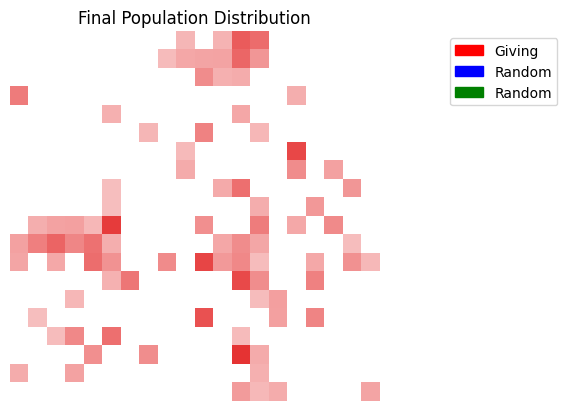

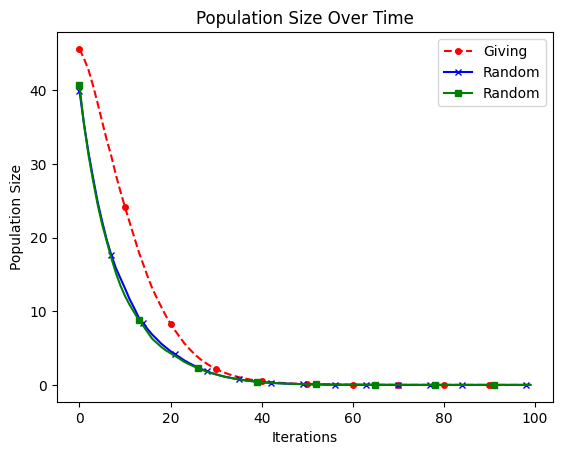

Creating simulation with parameters: bonus_0_0 - fitness_donation: 0.0 - fitness_growth: 0.0
Creating simulation: complete vs random

Final population fitness:
Population 1: complete - 0.00018458128033671528
Population 2: random - 5.3992614994058385e-05
Population 3: random - 5.3931395086692646e-05

Total fitness: 0.0002925052831415087

Final population %'s fitness:
Population 1: complete - 63.10%
Population 2: random - 18.46%
Population 3: random - 18.44%



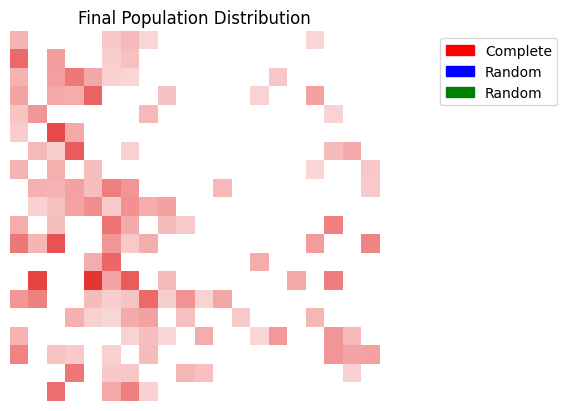

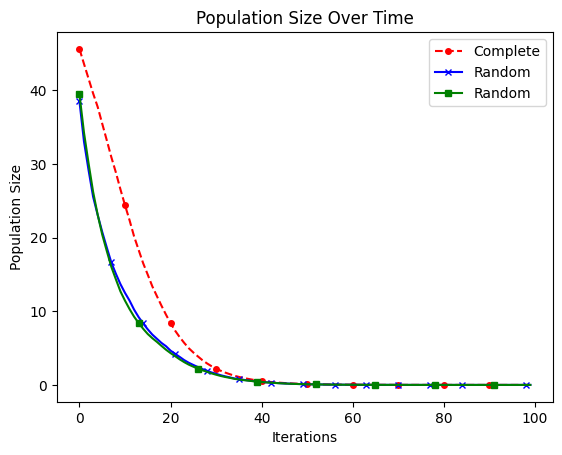

Creating simulation with parameters: bonus_0_0 - fitness_donation: 0.0 - fitness_growth: 0.0
Creating simulation: complete vs giving vs attacking

Final population fitness:
Population 1: complete - 0.6293997168540955
Population 2: giving - 0.6495268940925598
Population 3: attacking - 25.6583194732666

Total fitness: 26.937246322631836

Final population %'s fitness:
Population 1: complete - 2.34%
Population 2: giving - 2.41%
Population 3: attacking - 95.25%



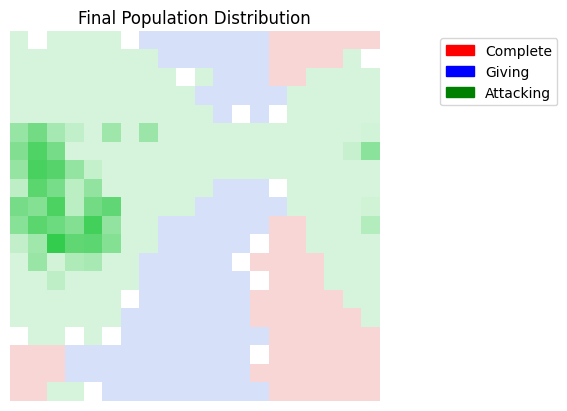

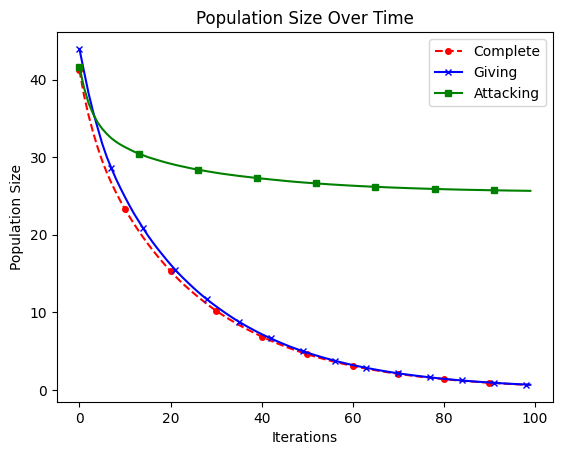

Creating simulation with parameters: bonus_0_04 - fitness_donation: 0.0 - fitness_growth: 0.04
Creating simulation: attack vs random

Final population fitness:
Population 1: attacking - 77.72530364990234
Population 2: random - 53.947296142578125
Population 3: random - 53.947296142578125

Total fitness: 185.61990356445312

Final population %'s fitness:
Population 1: attacking - 41.87%
Population 2: random - 29.06%
Population 3: random - 29.06%



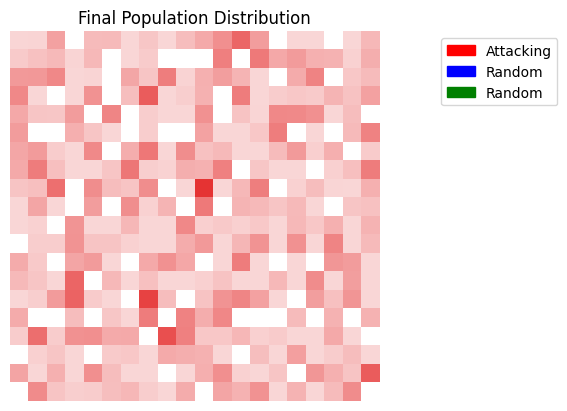

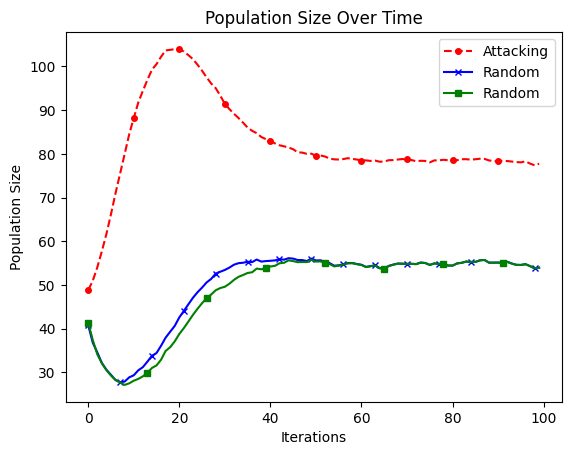

Creating simulation with parameters: bonus_0_04 - fitness_donation: 0.0 - fitness_growth: 0.04
Creating simulation: giving vs random

Final population fitness:
Population 1: giving - 74.52709197998047
Population 2: random - 53.1495475769043
Population 3: random - 53.1495475769043

Total fitness: 180.82618713378906

Final population %'s fitness:
Population 1: giving - 41.21%
Population 2: random - 29.39%
Population 3: random - 29.39%



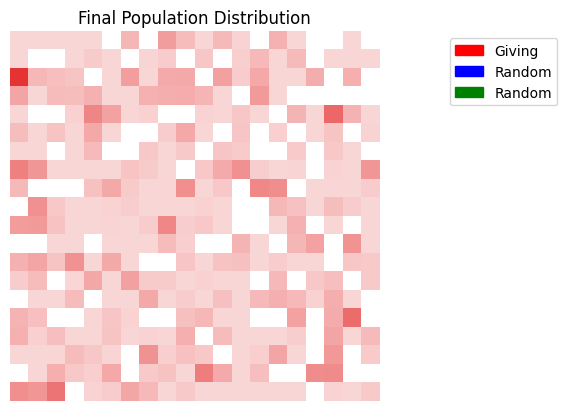

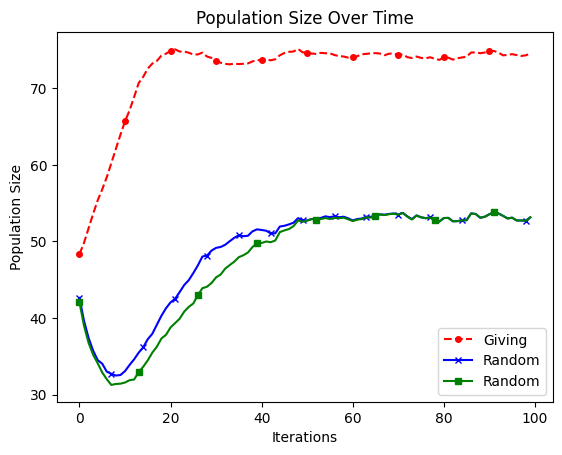

Creating simulation with parameters: bonus_0_04 - fitness_donation: 0.0 - fitness_growth: 0.04
Creating simulation: complete vs random

Final population fitness:
Population 1: complete - 74.54493713378906
Population 2: random - 53.01759719848633
Population 3: random - 53.01759719848633

Total fitness: 180.5801239013672

Final population %'s fitness:
Population 1: complete - 41.28%
Population 2: random - 29.36%
Population 3: random - 29.36%



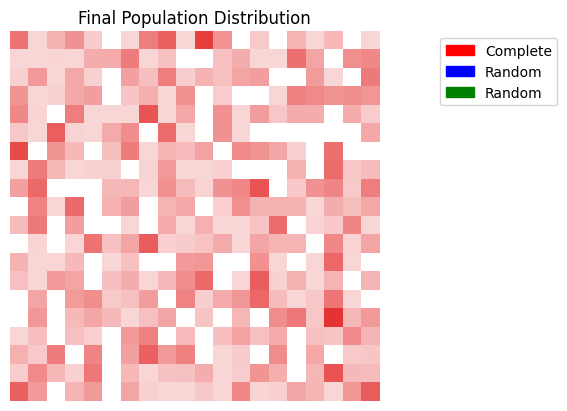

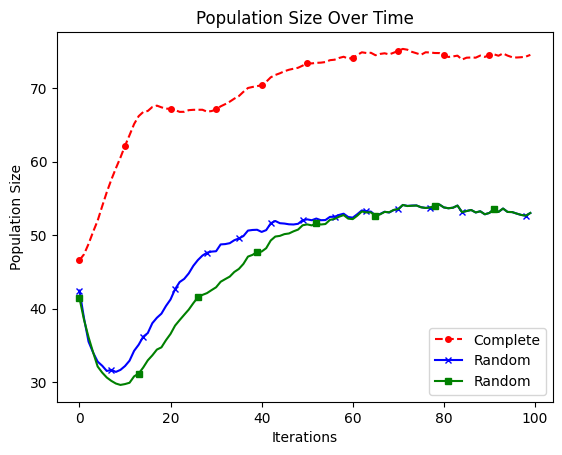

Creating simulation with parameters: bonus_0_04 - fitness_donation: 0.0 - fitness_growth: 0.04
Creating simulation: complete vs giving vs attacking

Final population fitness:
Population 1: complete - 39.35066223144531
Population 2: giving - 36.264320373535156
Population 3: attacking - 716.59716796875

Total fitness: 792.212158203125

Final population %'s fitness:
Population 1: complete - 4.97%
Population 2: giving - 4.58%
Population 3: attacking - 90.46%



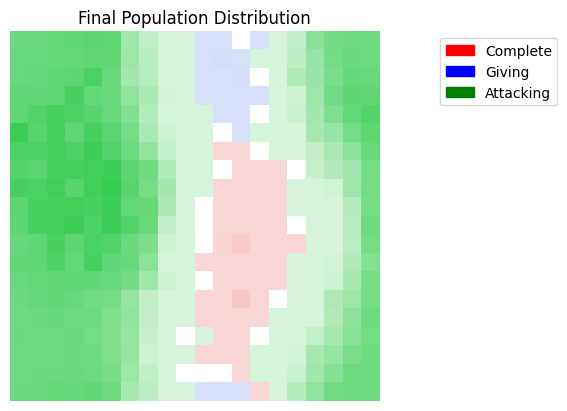

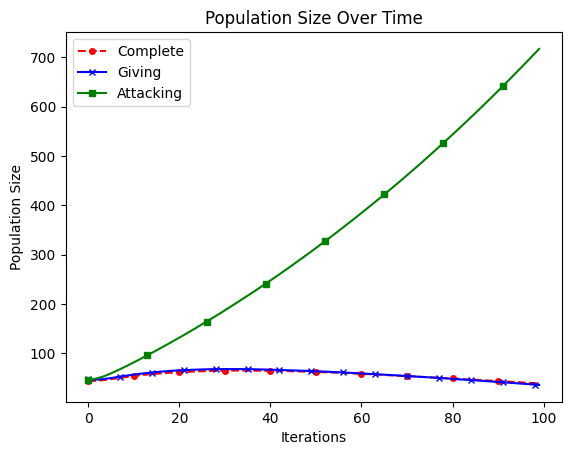

Creating simulation with parameters: bonus_04_0 - fitness_donation: 0.04 - fitness_growth: 0.0
Creating simulation: attack vs random

Final population fitness:
Population 1: attacking - 0.0012322892434895039
Population 2: random - 0.00021432939684018493
Population 3: random - 0.00021432939684018493

Total fitness: 0.0016609481535851955

Final population %'s fitness:
Population 1: attacking - 74.19%
Population 2: random - 12.90%
Population 3: random - 12.90%



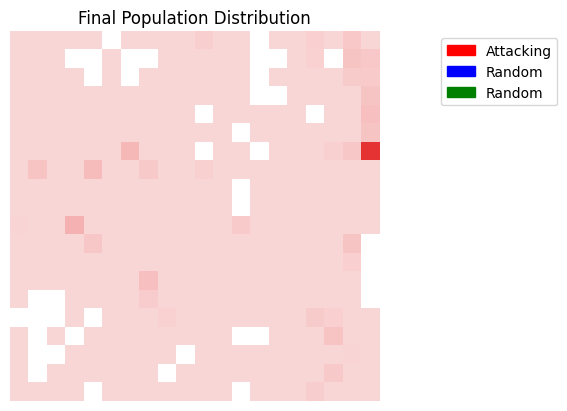

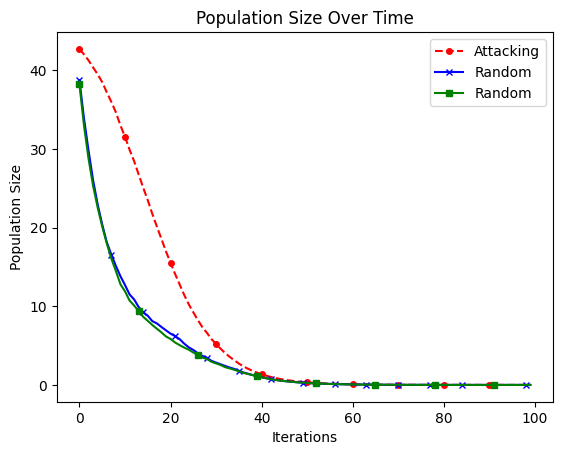

Creating simulation with parameters: bonus_04_0 - fitness_donation: 0.04 - fitness_growth: 0.0
Creating simulation: giving vs random

Final population fitness:
Population 1: giving - 0.0010646767914295197
Population 2: random - 0.00048438983503729105
Population 3: random - 0.00048438983503729105

Total fitness: 0.0020334564615041018

Final population %'s fitness:
Population 1: giving - 52.36%
Population 2: random - 23.82%
Population 3: random - 23.82%



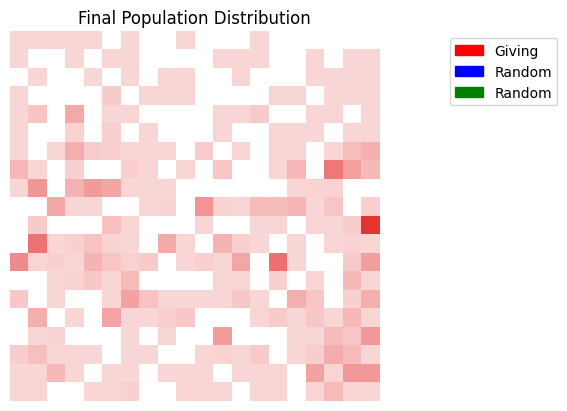

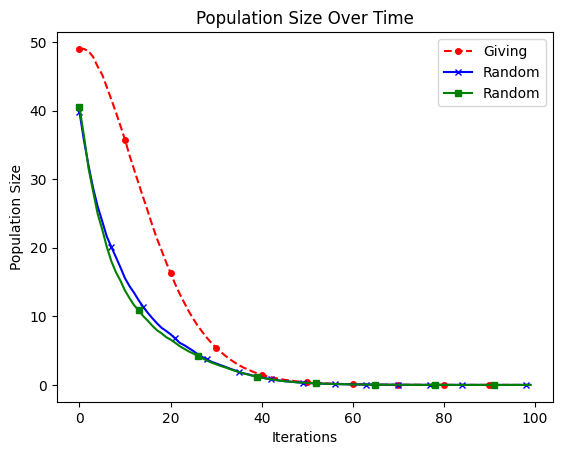

Creating simulation with parameters: bonus_04_0 - fitness_donation: 0.04 - fitness_growth: 0.0
Creating simulation: complete vs random

Final population fitness:
Population 1: complete - 0.0009740583482198417
Population 2: random - 0.00044753451948054135
Population 3: random - 0.00044753451948054135

Total fitness: 0.0018691273871809244

Final population %'s fitness:
Population 1: complete - 52.11%
Population 2: random - 23.94%
Population 3: random - 23.94%



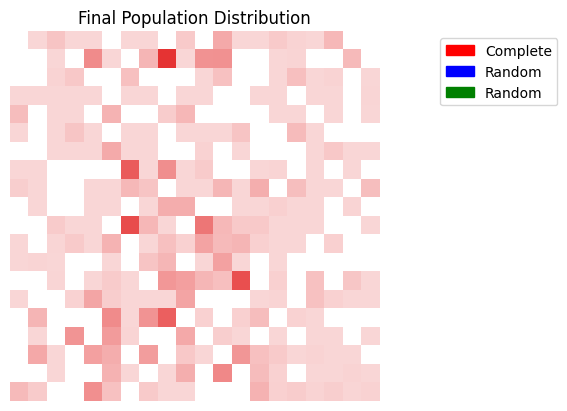

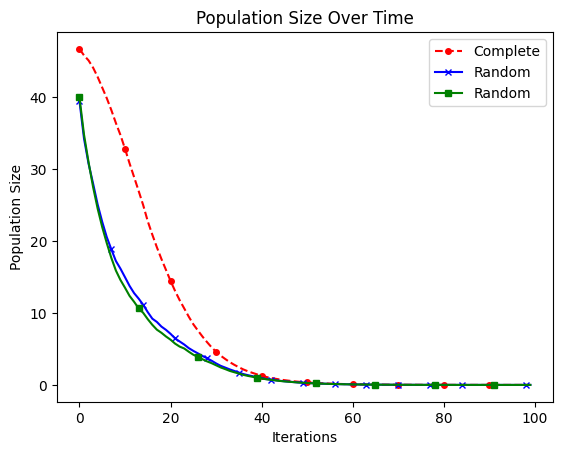

Creating simulation with parameters: bonus_04_0 - fitness_donation: 0.04 - fitness_growth: 0.0
Creating simulation: complete vs giving vs attacking

Final population fitness:
Population 1: complete - 13.781572341918945
Population 2: giving - 12.647439002990723
Population 3: attacking - 25.820608139038086

Total fitness: 52.24961853027344

Final population %'s fitness:
Population 1: complete - 26.38%
Population 2: giving - 24.21%
Population 3: attacking - 49.42%



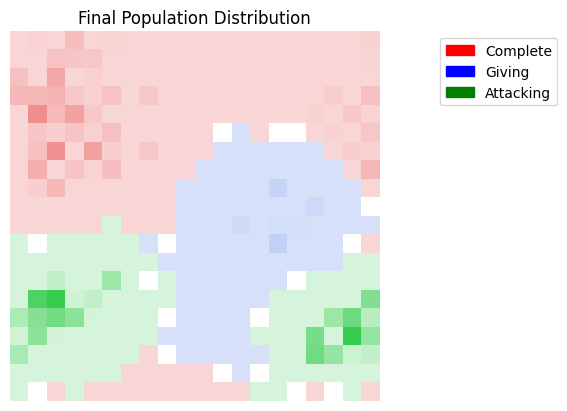

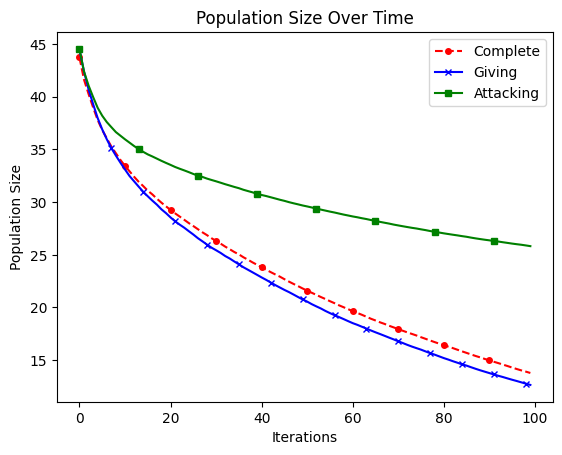

Creating simulation with parameters: bonus_04_04 - fitness_donation: 0.04 - fitness_growth: 0.04
Creating simulation: attack vs random

Final population fitness:
Population 1: attacking - 86.66693115234375
Population 2: random - 60.213043212890625
Population 3: random - 60.213043212890625

Total fitness: 207.093017578125

Final population %'s fitness:
Population 1: attacking - 41.85%
Population 2: random - 29.08%
Population 3: random - 29.08%



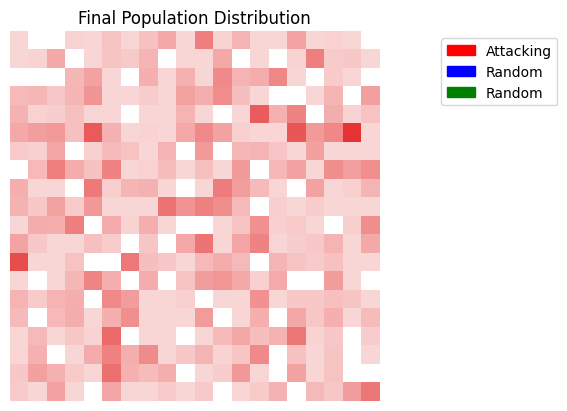

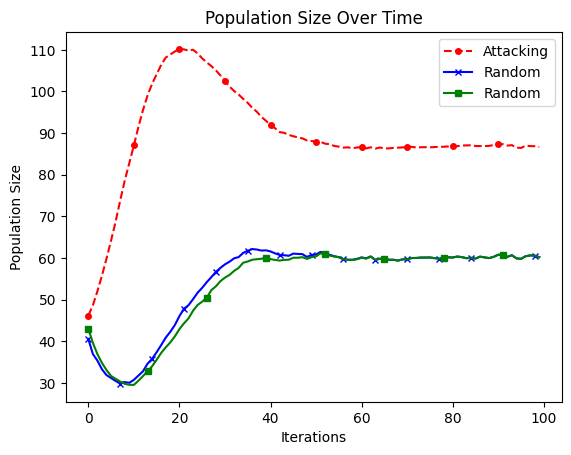

Creating simulation with parameters: bonus_04_04 - fitness_donation: 0.04 - fitness_growth: 0.04
Creating simulation: giving vs random

Final population fitness:
Population 1: giving - 84.85498809814453
Population 2: random - 60.06861877441406
Population 3: random - 60.06861877441406

Total fitness: 204.9922332763672

Final population %'s fitness:
Population 1: giving - 41.39%
Population 2: random - 29.30%
Population 3: random - 29.30%



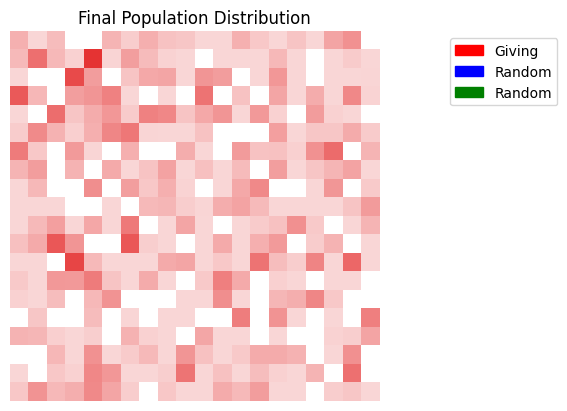

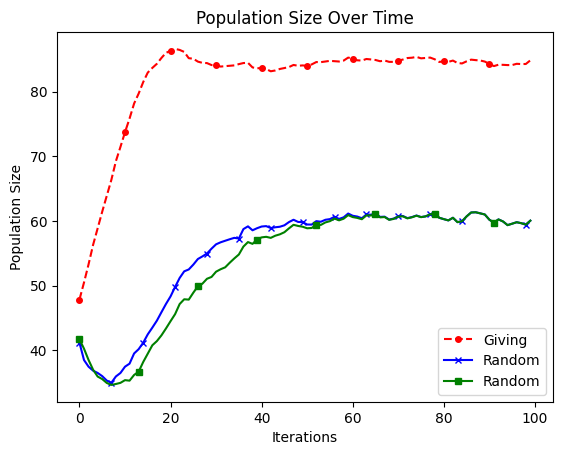

Creating simulation with parameters: bonus_04_04 - fitness_donation: 0.04 - fitness_growth: 0.04
Creating simulation: complete vs random

Final population fitness:
Population 1: complete - 84.3849105834961
Population 2: random - 59.89823913574219
Population 3: random - 59.89823913574219

Total fitness: 204.18138122558594

Final population %'s fitness:
Population 1: complete - 41.33%
Population 2: random - 29.34%
Population 3: random - 29.34%



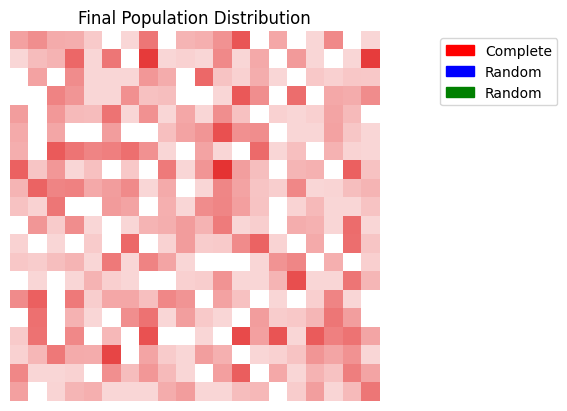

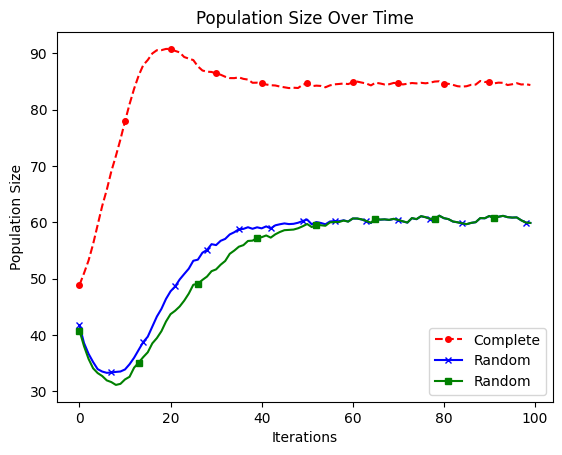

Creating simulation with parameters: bonus_04_04 - fitness_donation: 0.04 - fitness_growth: 0.04
Creating simulation: complete vs giving vs attacking

Final population fitness:
Population 1: complete - 160.8363037109375
Population 2: giving - 139.11209106445312
Population 3: attacking - 615.0040893554688

Total fitness: 914.9525146484375

Final population %'s fitness:
Population 1: complete - 17.58%
Population 2: giving - 15.20%
Population 3: attacking - 67.22%



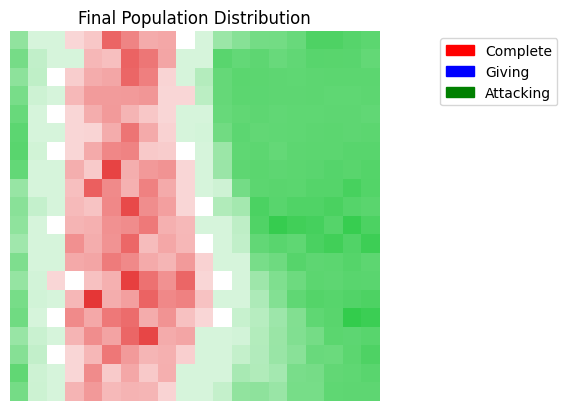

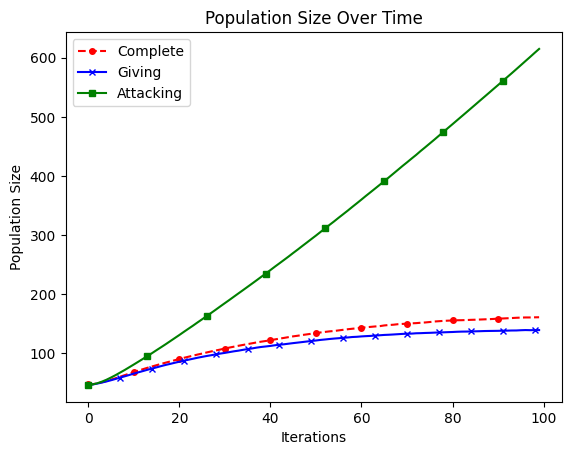

Creating simulation with parameters: bonus_08_0 - fitness_donation: 0.08 - fitness_growth: 0.0
Creating simulation: attack vs random

Final population fitness:
Population 1: attacking - 0.002663174644112587
Population 2: random - 0.0013192419428378344
Population 3: random - 0.0013192419428378344

Total fitness: 0.005301658064126968

Final population %'s fitness:
Population 1: attacking - 50.23%
Population 2: random - 24.88%
Population 3: random - 24.88%



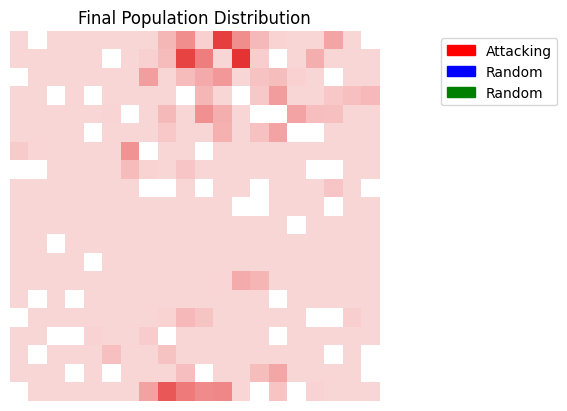

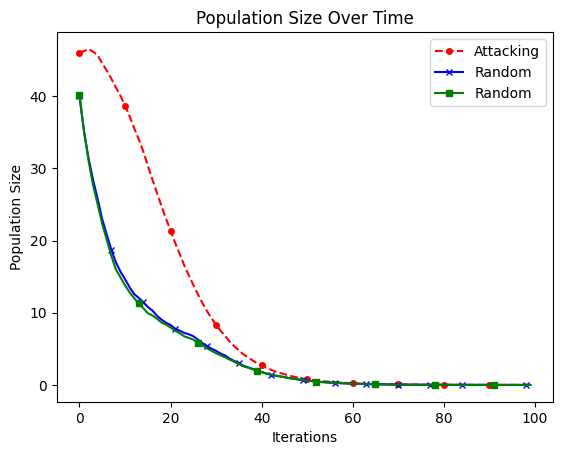

Creating simulation with parameters: bonus_08_0 - fitness_donation: 0.08 - fitness_growth: 0.0
Creating simulation: giving vs random

Final population fitness:
Population 1: giving - 0.004104325547814369
Population 2: random - 0.002810485428199172
Population 3: random - 0.002810485428199172

Total fitness: 0.009725296869874

Final population %'s fitness:
Population 1: giving - 42.20%
Population 2: random - 28.90%
Population 3: random - 28.90%



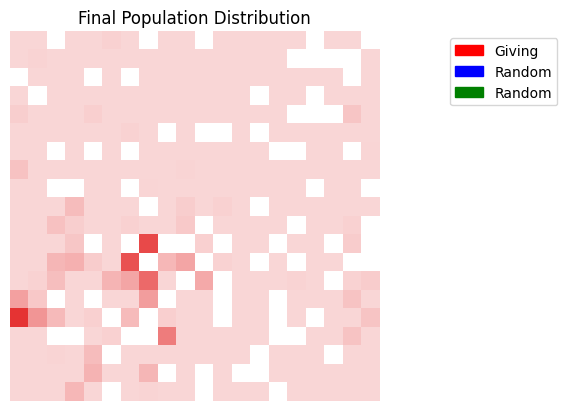

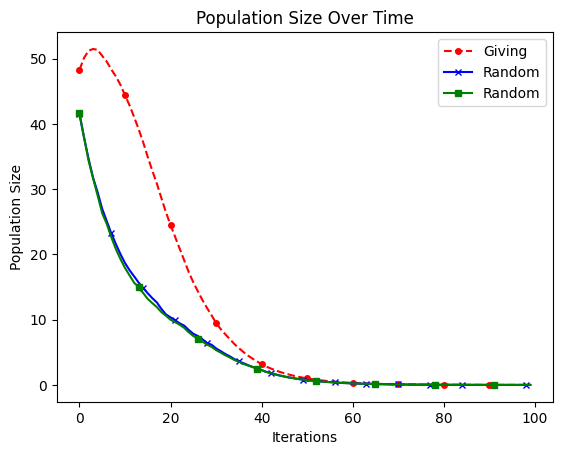

Creating simulation with parameters: bonus_08_0 - fitness_donation: 0.08 - fitness_growth: 0.0
Creating simulation: complete vs random

Final population fitness:
Population 1: complete - 0.004335095174610615
Population 2: random - 0.002995067276060581
Population 3: random - 0.002995067276060581

Total fitness: 0.010325229726731777

Final population %'s fitness:
Population 1: complete - 41.99%
Population 2: random - 29.01%
Population 3: random - 29.01%



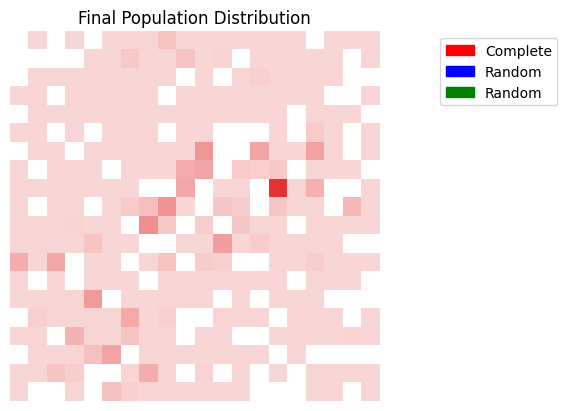

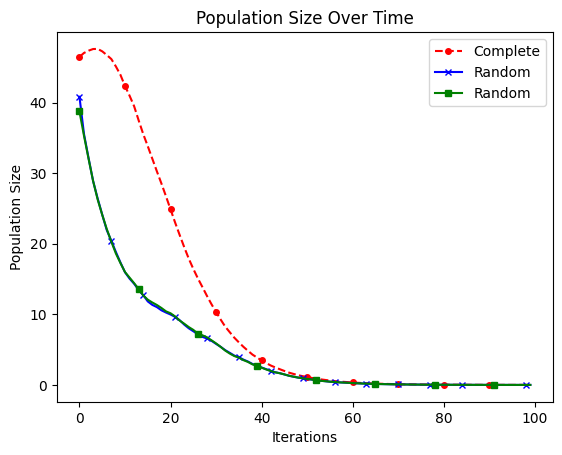

Creating simulation with parameters: bonus_08_0 - fitness_donation: 0.08 - fitness_growth: 0.0
Creating simulation: complete vs giving vs attacking

Final population fitness:
Population 1: complete - 220.6361083984375
Population 2: giving - 320.7608337402344
Population 3: attacking - 15.919546127319336

Total fitness: 557.3165283203125

Final population %'s fitness:
Population 1: complete - 39.59%
Population 2: giving - 57.55%
Population 3: attacking - 2.86%



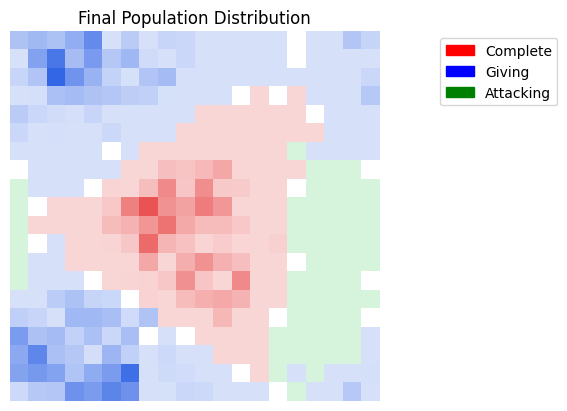

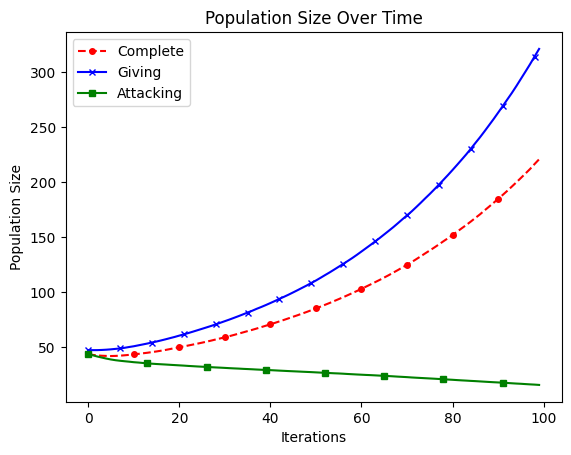

Creating simulation with parameters: bonus_08_04 - fitness_donation: 0.08 - fitness_growth: 0.4
Creating simulation: attack vs random

Final population fitness:
Population 1: attacking - 980.6383666992188
Population 2: random - 673.9352416992188
Population 3: random - 673.9352416992188

Total fitness: 2328.5087890625

Final population %'s fitness:
Population 1: attacking - 42.11%
Population 2: random - 28.94%
Population 3: random - 28.94%



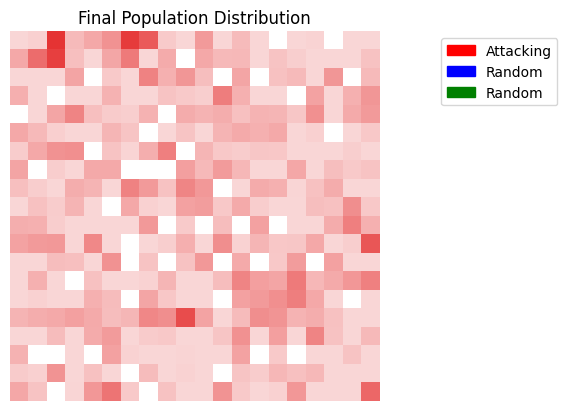

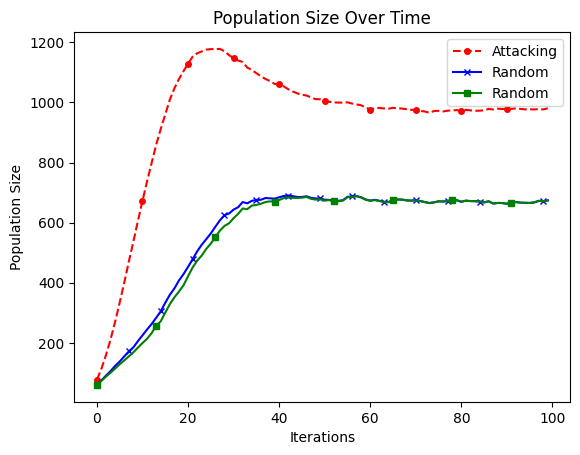

Creating simulation with parameters: bonus_08_04 - fitness_donation: 0.08 - fitness_growth: 0.4
Creating simulation: giving vs random

Final population fitness:
Population 1: giving - 987.83154296875
Population 2: random - 707.689453125
Population 3: random - 707.689453125

Total fitness: 2403.21044921875

Final population %'s fitness:
Population 1: giving - 41.10%
Population 2: random - 29.45%
Population 3: random - 29.45%



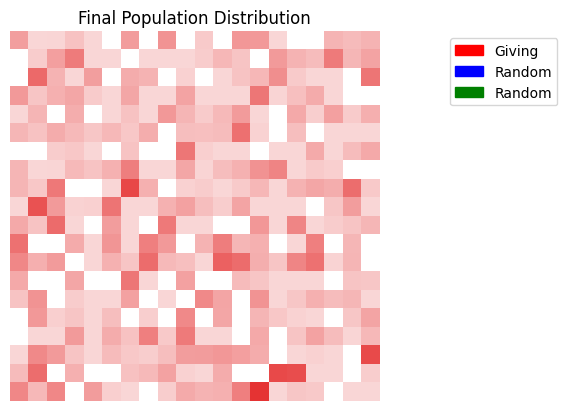

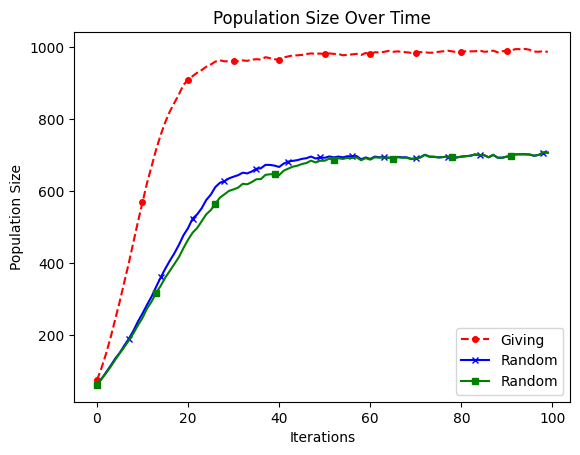

Creating simulation with parameters: bonus_08_04 - fitness_donation: 0.08 - fitness_growth: 0.4
Creating simulation: complete vs random

Final population fitness:
Population 1: complete - 988.1890869140625
Population 2: random - 711.818603515625
Population 3: random - 711.818603515625

Total fitness: 2411.826171875

Final population %'s fitness:
Population 1: complete - 40.97%
Population 2: random - 29.51%
Population 3: random - 29.51%



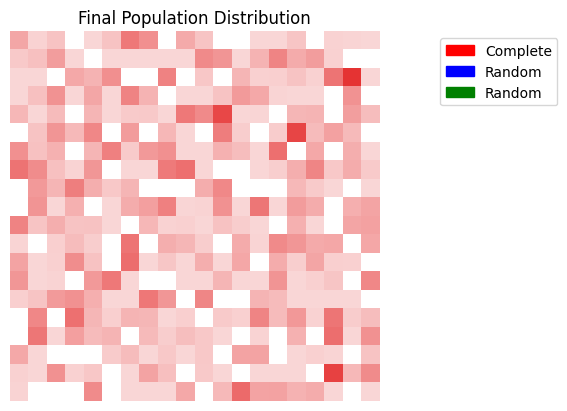

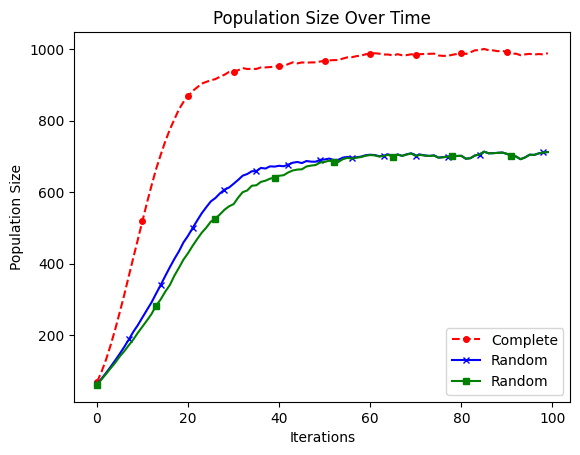

Creating simulation with parameters: bonus_08_04 - fitness_donation: 0.08 - fitness_growth: 0.4
Creating simulation: complete vs giving vs attacking

Final population fitness:
Population 1: complete - 6299.48486328125
Population 2: giving - 8245.009765625
Population 3: attacking - 4918.57861328125

Total fitness: 19463.072265625

Final population %'s fitness:
Population 1: complete - 32.37%
Population 2: giving - 42.36%
Population 3: attacking - 25.27%



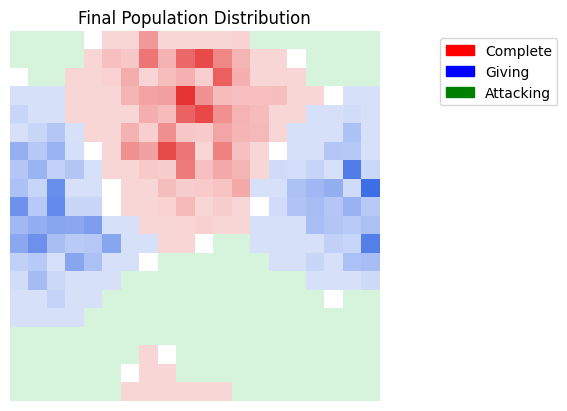

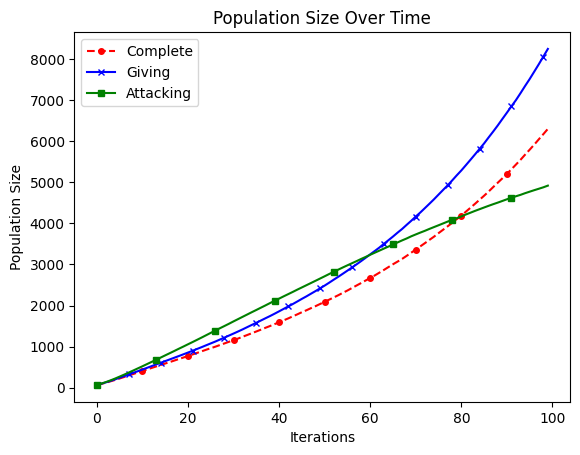

Creating simulation with parameters: bonus_0_08 - fitness_donation: 0.0 - fitness_growth: 0.08
Creating simulation: attack vs random

Final population fitness:
Population 1: attacking - 156.103759765625
Population 2: random - 108.29872131347656
Population 3: random - 108.29872131347656

Total fitness: 372.701171875

Final population %'s fitness:
Population 1: attacking - 41.88%
Population 2: random - 29.06%
Population 3: random - 29.06%



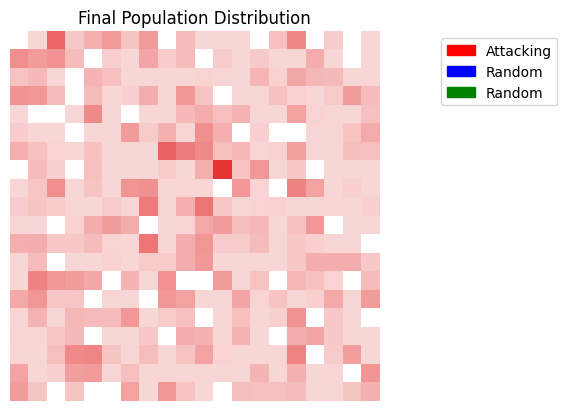

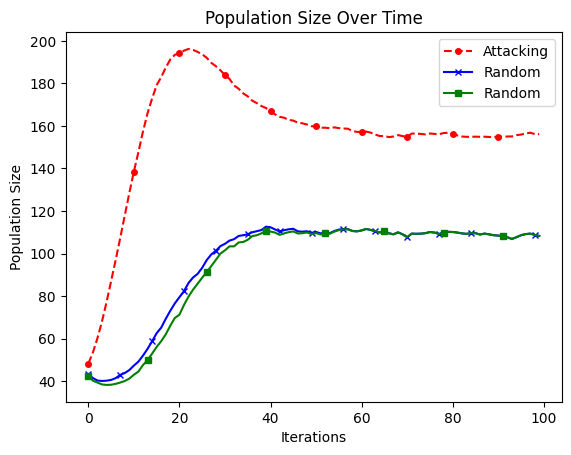

Creating simulation with parameters: bonus_0_08 - fitness_donation: 0.0 - fitness_growth: 0.08
Creating simulation: giving vs random

Final population fitness:
Population 1: giving - 147.8696746826172
Population 2: random - 106.39097595214844
Population 3: random - 106.39097595214844

Total fitness: 360.651611328125

Final population %'s fitness:
Population 1: giving - 41.00%
Population 2: random - 29.50%
Population 3: random - 29.50%



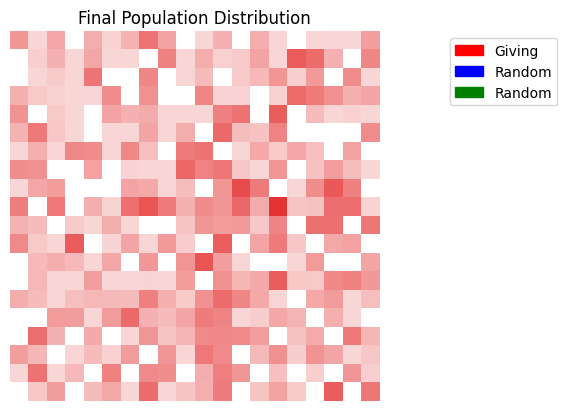

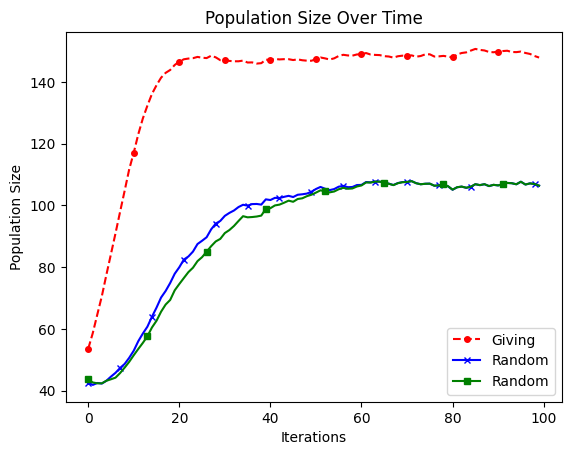

Creating simulation with parameters: bonus_0_08 - fitness_donation: 0.0 - fitness_growth: 0.08
Creating simulation: complete vs random

Final population fitness:
Population 1: complete - 149.16441345214844
Population 2: random - 106.69029235839844
Population 3: random - 106.69029235839844

Total fitness: 362.54498291015625

Final population %'s fitness:
Population 1: complete - 41.14%
Population 2: random - 29.43%
Population 3: random - 29.43%



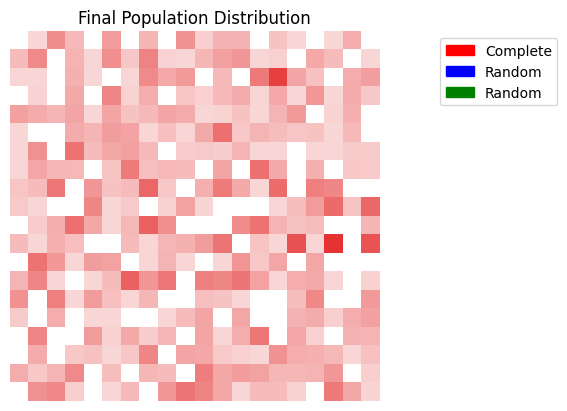

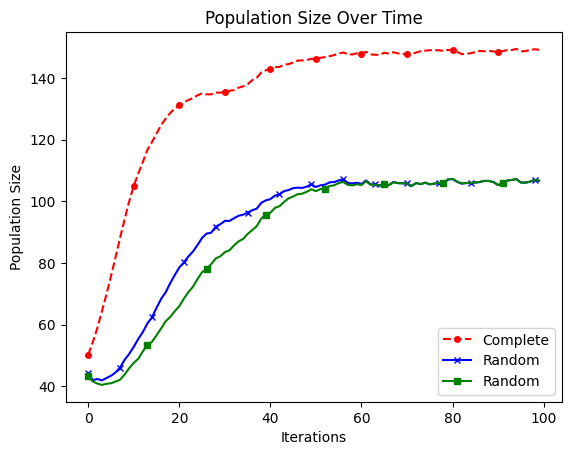

Creating simulation with parameters: bonus_0_08 - fitness_donation: 0.0 - fitness_growth: 0.08
Creating simulation: complete vs giving vs attacking

Final population fitness:
Population 1: complete - 64.21240234375
Population 2: giving - 68.81940460205078
Population 3: attacking - 1475.7659912109375

Total fitness: 1608.7978515625

Final population %'s fitness:
Population 1: complete - 3.99%
Population 2: giving - 4.28%
Population 3: attacking - 91.73%



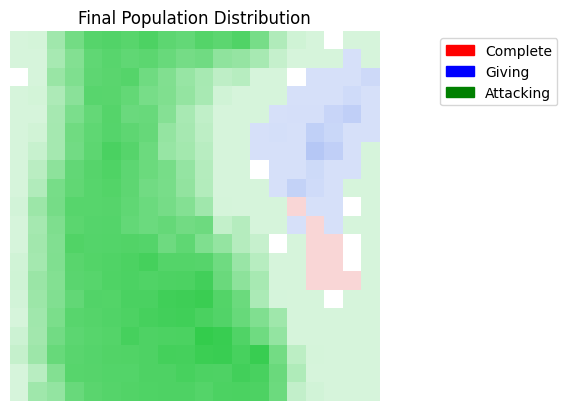

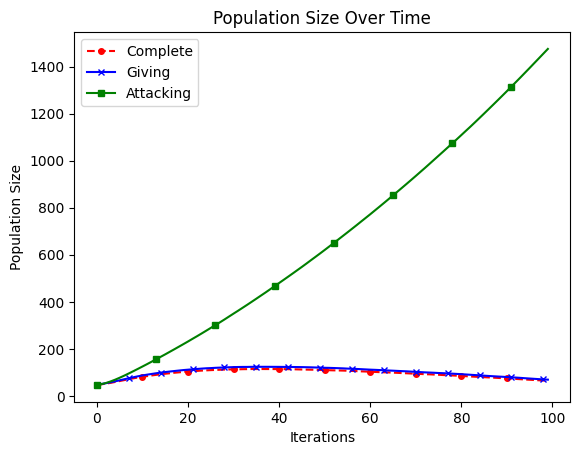

Creating simulation with parameters: bonus_04_08 - fitness_donation: 0.04 - fitness_growth: 0.08
Creating simulation: attack vs random

Final population fitness:
Population 1: attacking - 173.78773498535156
Population 2: random - 120.16320037841797
Population 3: random - 120.16320037841797

Total fitness: 414.1141357421875

Final population %'s fitness:
Population 1: attacking - 41.97%
Population 2: random - 29.02%
Population 3: random - 29.02%



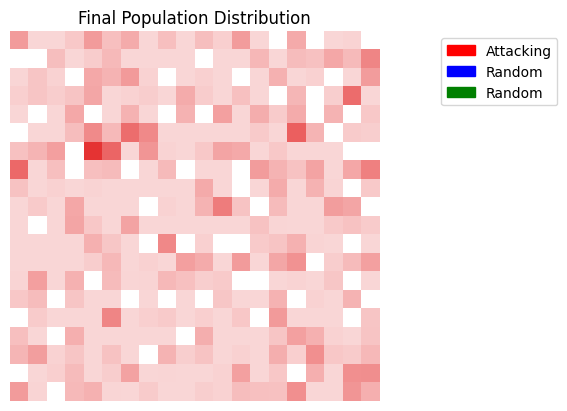

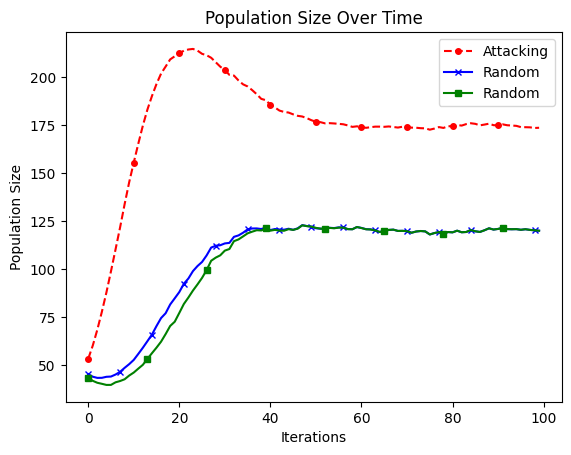

Creating simulation with parameters: bonus_04_08 - fitness_donation: 0.04 - fitness_growth: 0.08
Creating simulation: giving vs random

Final population fitness:
Population 1: giving - 170.37799072265625
Population 2: random - 120.77412414550781
Population 3: random - 120.77412414550781

Total fitness: 411.92620849609375

Final population %'s fitness:
Population 1: giving - 41.36%
Population 2: random - 29.32%
Population 3: random - 29.32%



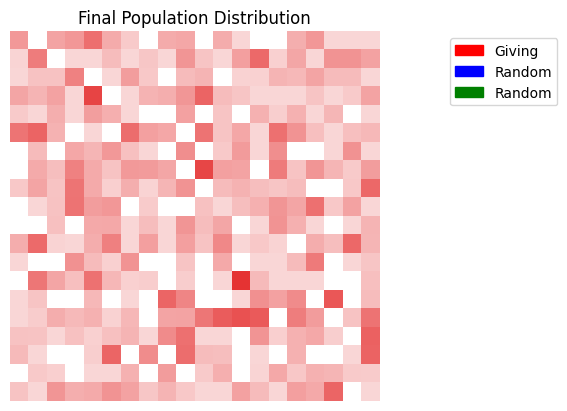

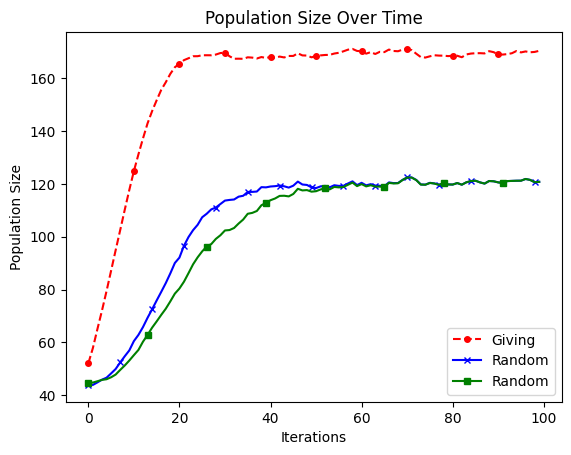

Creating simulation with parameters: bonus_04_08 - fitness_donation: 0.04 - fitness_growth: 0.08
Creating simulation: complete vs random

Final population fitness:
Population 1: complete - 169.79026794433594
Population 2: random - 121.97119140625
Population 3: random - 121.97119140625

Total fitness: 413.732666015625

Final population %'s fitness:
Population 1: complete - 41.04%
Population 2: random - 29.48%
Population 3: random - 29.48%



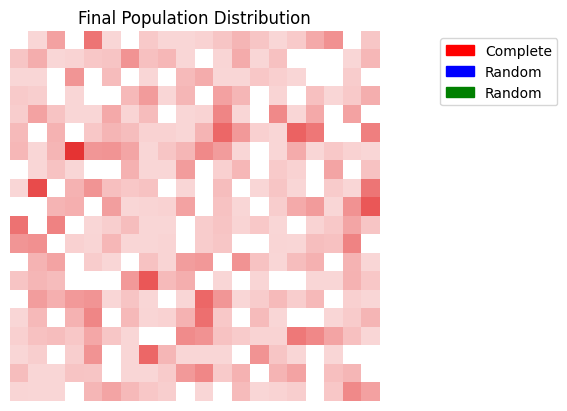

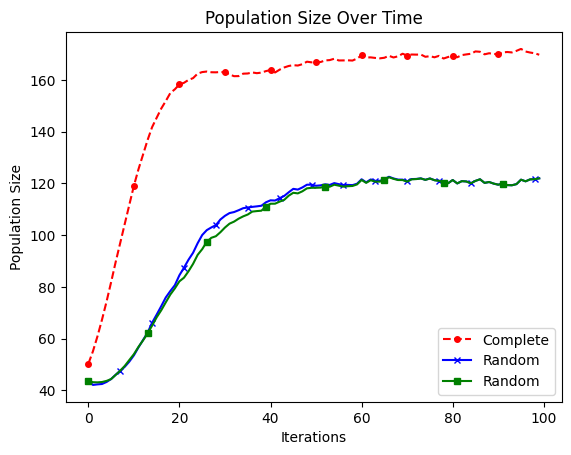

Creating simulation with parameters: bonus_04_08 - fitness_donation: 0.04 - fitness_growth: 0.08
Creating simulation: complete vs giving vs attacking

Final population fitness:
Population 1: complete - 280.90899658203125
Population 2: giving - 254.08697509765625
Population 3: attacking - 1239.68798828125

Total fitness: 1774.6839599609375

Final population %'s fitness:
Population 1: complete - 15.83%
Population 2: giving - 14.32%
Population 3: attacking - 69.85%



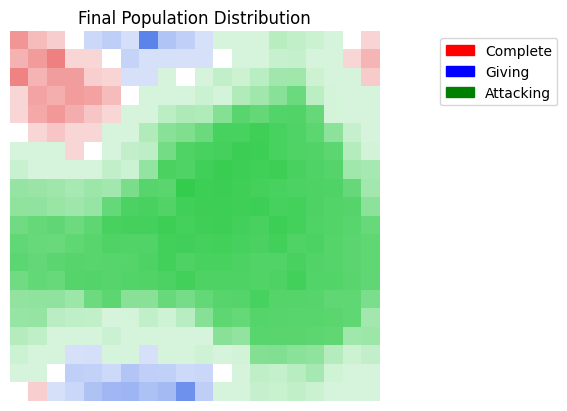

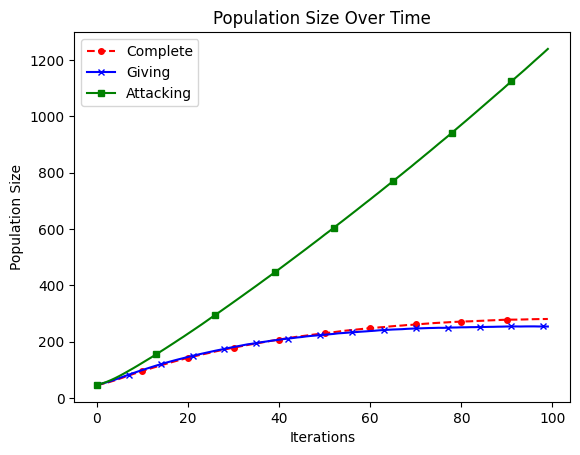

Creating simulation with parameters: bonus_08_08 - fitness_donation: 0.08 - fitness_growth: 0.08
Creating simulation: attack vs random

Final population fitness:
Population 1: attacking - 194.51051330566406
Population 2: random - 134.36514282226562
Population 3: random - 134.36514282226562

Total fitness: 463.2408142089844

Final population %'s fitness:
Population 1: attacking - 41.99%
Population 2: random - 29.01%
Population 3: random - 29.01%



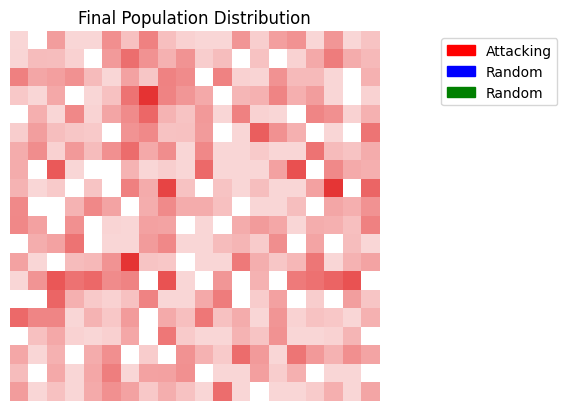

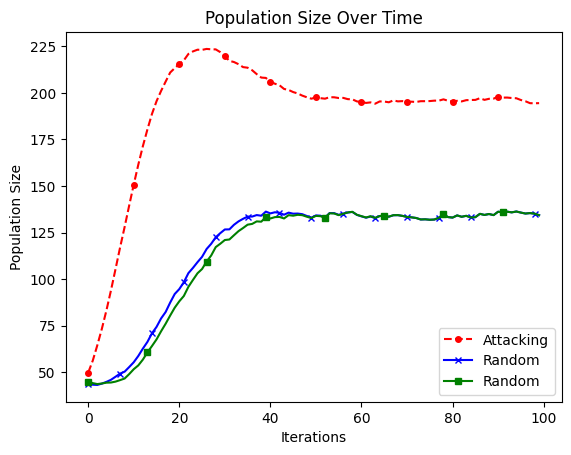

Creating simulation with parameters: bonus_08_08 - fitness_donation: 0.08 - fitness_growth: 0.08
Creating simulation: giving vs random

Final population fitness:
Population 1: giving - 198.0105438232422
Population 2: random - 140.1980438232422
Population 3: random - 140.1980438232422

Total fitness: 478.4066162109375

Final population %'s fitness:
Population 1: giving - 41.39%
Population 2: random - 29.31%
Population 3: random - 29.31%



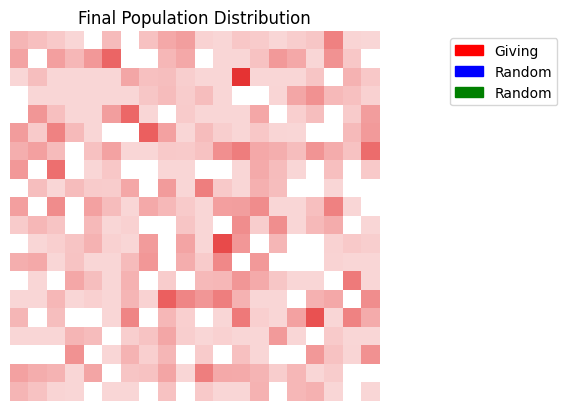

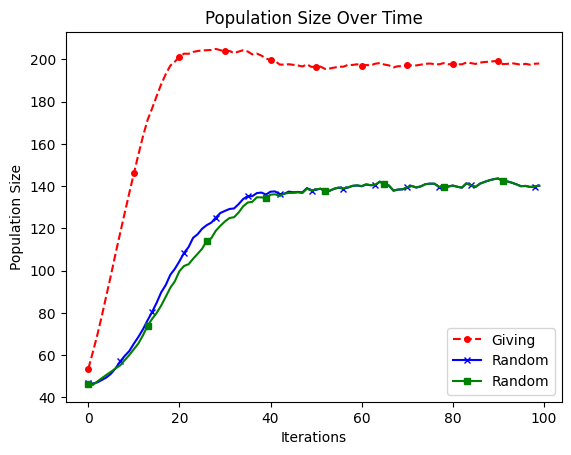

Creating simulation with parameters: bonus_08_08 - fitness_donation: 0.08 - fitness_growth: 0.08
Creating simulation: complete vs random

Final population fitness:
Population 1: complete - 195.99078369140625
Population 2: random - 141.24429321289062
Population 3: random - 141.24429321289062

Total fitness: 478.4793701171875

Final population %'s fitness:
Population 1: complete - 40.96%
Population 2: random - 29.52%
Population 3: random - 29.52%



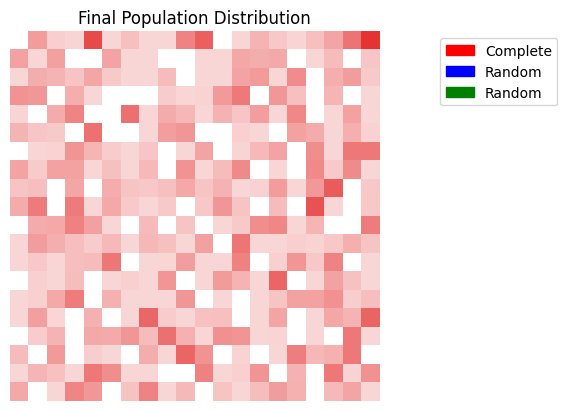

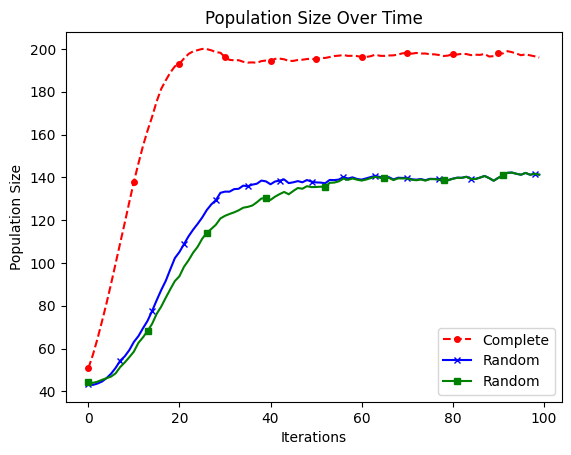

Creating simulation with parameters: bonus_08_08 - fitness_donation: 0.08 - fitness_growth: 0.08
Creating simulation: complete vs giving vs attacking

Final population fitness:
Population 1: complete - 1648.4381103515625
Population 2: giving - 1900.184326171875
Population 3: attacking - 869.7787475585938

Total fitness: 4418.4013671875

Final population %'s fitness:
Population 1: complete - 37.31%
Population 2: giving - 43.01%
Population 3: attacking - 19.69%



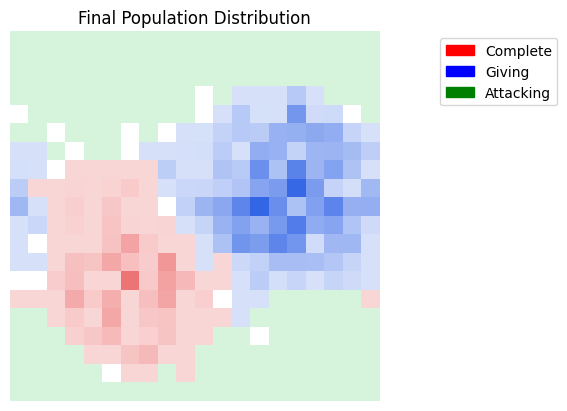

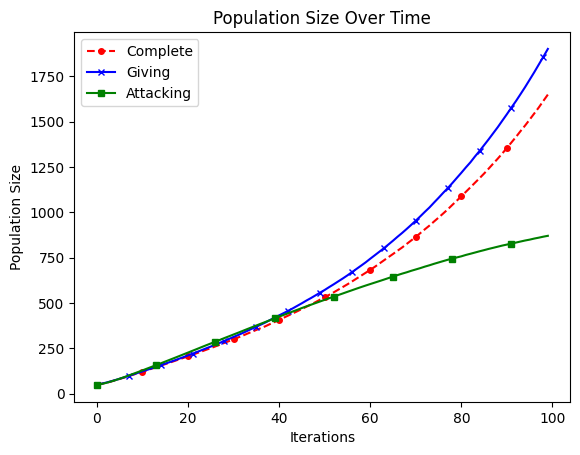

In [ ]:
"""# if save_dir is None, the images will not be saved

simulation_parameters = [('bonus_0_0', 0.0, 0.0), ('bonus_0_04', 0.0, 0.04), ('bonus_04_0', 0.04, 0.0), ('bonus_04_04', 0.04, 0.04), ('bonus_08_0', 0.08, 0.0), ('bonus_08_04', 0.08, 0.4), ('bonus_0_08', 0.0, 0.08), ('bonus_04_08', 0.04, 0.08), ('bonus_08_08', 0.08, 0.08)]

all_results_string = 'pop1 total fitness; pop2 total fitness; pop2 total fitness; pop1 \% fitness; pop 2 \% fitness; pop 3 \% fitness \n'

parent_dir = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
SAVE_DIR = os.path.join(parent_dir, 'simulation_imgs')
#SAVE_DIR = None

if SAVE_DIR is not None:
    os.makedirs(SAVE_DIR, exist_ok=True)

# Number of iterations 
iterations = 100

# Simulation parameters
nb_batches = 50
rows, cols = 20, 20
populations = {
    "red": {"p": 0.2, "mean_v": 1.0, "std_v": 0.1},
    "blue": {"p": 0.2, "mean_v": 1.0, "std_v": 0.1},
    "green": {"p": 0.2, "mean_v": 1.0, "std_v": 0.1},
}
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

for tup in simulation_parameters:

    sub_dir_name = tup[0]
    fitness_donation = tup[1]
    fitness_growth = tup[2]

    title = f"don_{fitness_donation}_growth_{fitness_growth}"

    print(f"Creating simulation with parameters: {sub_dir_name} - fitness_donation: {fitness_donation} - fitness_growth: {fitness_growth}")

    # Create the simulation "attack vs random"

    print("Creating simulation: attack vs random")
    simulation = SquareSimulation(nb_batch=nb_batches, rows=rows, cols=cols,
                                    populations=populations, device=device, 
                                    FITNESS_DONATION_BONUS=fitness_donation, FITNESS_GROWTH_VALUE=fitness_growth)
    simulation.reset()

    if SAVE_DIR is not None:
        tmp_dir = os.path.join(SAVE_DIR, 'attackVsRandom')
        os.makedirs(tmp_dir, exist_ok=True)
    else:
        tmp_dir = None
    results = get_results_imgs(simulation, iterations=iterations, save_dir=tmp_dir, type1='attacking', title=title)

    if SAVE_DIR is not None:
        results_string = f"Simulation: {title} - attack vs random\n{results}\n"
        all_results_string += results_string + "\n"

    print(f"Creating simulation with parameters: {sub_dir_name} - fitness_donation: {fitness_donation} - fitness_growth: {fitness_growth}")

    # Create the simulation "giving vs random"
    print("Creating simulation: giving vs random")
    simulation = SquareSimulation(nb_batch=nb_batches, rows=rows, cols=cols,
                                    populations=populations, device=device, 
                                    FITNESS_DONATION_BONUS=fitness_donation, FITNESS_GROWTH_VALUE=fitness_growth)
    simulation.reset()

    if SAVE_DIR is not None:
        tmp_dir = os.path.join(SAVE_DIR, 'givingVsRandom')
        os.makedirs(tmp_dir, exist_ok=True)
    else:
        tmp_dir = None

    results = get_results_imgs(simulation, iterations=iterations, type1='giving', save_dir=tmp_dir, title=title)

    if SAVE_DIR is not None:
        results_string = f"Simulation: {title} - giving vs random\n{results}\n"
        all_results_string += results_string + "\n"
    print(f"Creating simulation with parameters: {sub_dir_name} - fitness_donation: {fitness_donation} - fitness_growth: {fitness_growth}")

    # Create the simulation "complete vs random"
    print("Creating simulation: complete vs random")
    simulation = SquareSimulation(nb_batch=nb_batches, rows=rows, cols=cols,
                                    populations=populations, device=device, 
                                    FITNESS_DONATION_BONUS=fitness_donation, FITNESS_GROWTH_VALUE=fitness_growth)
    simulation.reset()

    if SAVE_DIR is not None:
        tmp_dir = os.path.join(SAVE_DIR, 'completeVsRandom')
        os.makedirs(tmp_dir, exist_ok=True)
    else:
        tmp_dir = None

    results = get_results_imgs(simulation, iterations=iterations, type1='complete', save_dir=tmp_dir, title=title)
    if SAVE_DIR is not None:
        results_string = f"Simulation: {title} - complete vs random\n{results}\n"
        all_results_string += results_string + "\n"
    print(f"Creating simulation with parameters: {sub_dir_name} - fitness_donation: {fitness_donation} - fitness_growth: {fitness_growth}")

    # Create the simulation "giving vs attacking vs complete"
    print("Creating simulation: complete vs giving vs attacking")
    simulation = SquareSimulation(nb_batch=nb_batches, rows=rows, cols=cols,
                                    populations=populations, device=device, 
                                    FITNESS_DONATION_BONUS=fitness_donation, FITNESS_GROWTH_VALUE=fitness_growth)
    simulation.reset()

    if SAVE_DIR is not None:
        tmp_dir = os.path.join(SAVE_DIR, 'completeVsGivingVsAttacking')
        os.makedirs(tmp_dir, exist_ok=True)
    else:
        tmp_dir = None

    results = get_results_imgs(simulation, iterations=iterations, type1='complete', type2='giving', type3='attacking', save_dir=tmp_dir, title=title)

    if SAVE_DIR is not None:
        results_string = f"Simulation: {title} - Complete vs Giving vs Attacking\n{results}\n"
        all_results_string += results_string + "\n""""